In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import ttest_ind # Import Two-sample T-Test
from scipy.stats import f_oneway # Import Anova
from statsmodels.stats.multicomp import pairwise_tukeyhsd # Import Tukey's Range Test
from scipy.stats import chi2_contingency # Import Chi Square Test
from scipy.stats import fisher_exact # Fisher's Exact Test

In [2]:
# load data
heart = pd.read_csv('heart_disease.csv')
heart.head()

,age,sex,trestbps,chol,cp,exang,fbs,thalach,heart_disease
0,63,male,145,233,typical angina,0,1,150,absence
1,67,male,160,286,asymptomatic,1,0,108,presence
2,67,male,120,229,asymptomatic,1,0,129,presence
3,37,male,130,250,non-anginal pain,0,0,187,absence
4,41,female,130,204,atypical angina,0,0,172,absence


### The variables in this data are:

+ age: age in years
+ sex: sex assigned at birth; 'male' or 'female'
+ trestbps: resting blood pressure in mm Hg
+ chol: serum cholesterol in mg/dl
+ cp: chest pain type ('typical angina', 'atypical angina', 'non-anginal pain', or 'asymptomatic')
+ exang: whether the patient experiences exercise-induced angina (1: yes; 0: no)
+ fbs: whether the patient’s fasting blood sugar is >120 mg/dl (1: yes; 0: no)
+ thalach: maximum heart rate achieved in exercise test
+ heart_disease: whether the patient is found to have heart disease ('presence': diagnosed with heart disease; 'absence': no heart disease)

In [3]:
heart.groupby('heart_disease').mean(numeric_only=True)

,age,trestbps,chol,exang,fbs,thalach
heart_disease,,,,,,
absence,52.585366,129.250000,242.640244,0.140244,0.140244,158.378049
presence,56.625899,134.568345,251.474820,0.546763,0.158273,139.258993


In [4]:
heart.groupby('heart_disease').median(numeric_only=True)

,age,trestbps,chol,exang,fbs,thalach
heart_disease,,,,,,
absence,52.0,130.0,234.5,0.0,0.0,161.0
presence,58.0,130.0,249.0,1.0,0.0,142.0


### Experiment:

Simulate that there is no difference between thalach true mean for people with heart disease and the true mean for people without heart disease

In [44]:
scramble = np.random.choice(heart.heart_disease, size = len(heart), replace=False)
simulated_thalach_hd = heart.thalach[scramble == 'presence']
simulated_thalach_no_hd = heart.thalach[scramble == 'absence']
simulated_mean_diff = simulated_thalach_hd.mean() - simulated_thalach_no_hd.mean()
print('Simulated mean difference:', simulated_mean_diff)

Simulated mean difference: 0.5661080891384529


Now we will run the simulated experiment 1000 times to see the distribution and if it will go near 0

In [ ]:
mean_diff_list = [] # we will store each result of the mean difference here

for experiment in range(1000):
    scramble = np.random.choice(heart.heart_disease, size = len(heart), replace=False)
    simulated_thalach_hd = heart.thalach[scramble == 'presence']
    simulated_thalach_no_hd = heart.thalach[scramble == 'absence']
    simulated_mean_diff = simulated_thalach_hd.mean() - simulated_thalach_no_hd.mean()
    mean_diff_list.append(simulated_mean_diff) # append the mean difference to the list

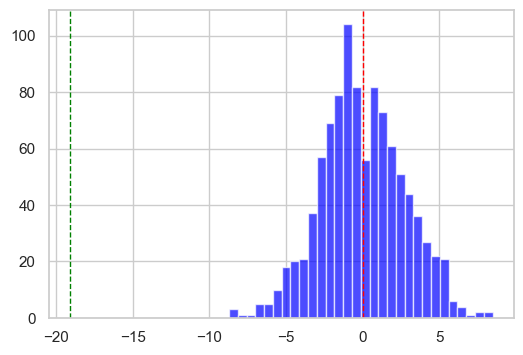

In [54]:
simulated_mean_diff = np.mean(mean_diff_list)
true_mean_thabalach_no_hd = heart.thalach[heart.heart_disease == 'absence'].mean()
true_mean_thalach_hd = heart.thalach[heart.heart_disease == 'presence'].mean()
true_mean_diff = true_mean_thalach_hd - true_mean_thabalach_no_hd

#visualize the distribution of the mean differences
plt.figure(figsize=(6, 4))
plt.hist(mean_diff_list, bins=30, color='blue', alpha=0.7)
plt.axvline(true_mean_diff, color='green', linestyle='dashed', linewidth=1) # True mean difference for people with heart disease
plt.axvline(simulated_mean_diff, color='red', linestyle='dashed', linewidth=1) # Simulated mean difference for people with heart disease

plt.show()

### Maximum heart rate (thalach) vs Heart Disease (heart_disease) - T-sample T-test

+ **Null**: The average thalach for a person with heart disease is equal to the average thalach for a person without heart disease.
+ **Alternative**: The average thalach for a person with heart disease is NOT equal to the average thalach for a person without heart disease.

This requires a two-sample t-test, which can be implemented using the ttest_ind() function from scipy.stats.

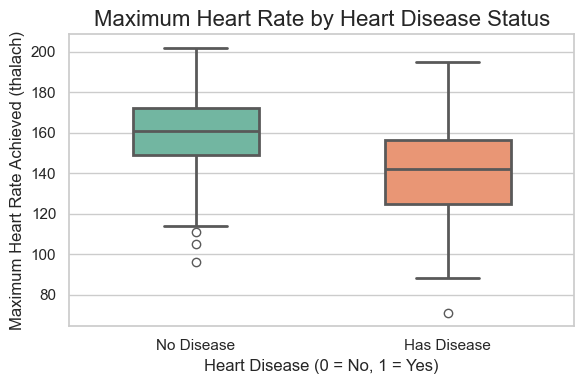

In [8]:
# Create the box plots to compare thalach for the different categories of heart desease
plt.figure(figsize=(6, 4))  # Wider figure
sns.set(style="whitegrid")  # Cleaner background
sns.boxplot(x='heart_disease', y='thalach',data=heart,palette='Set2', linewidth=2, width=0.5, hue='heart_disease', legend=False)
# Add labels and title
plt.title('Maximum Heart Rate by Heart Disease Status', fontsize=16)
plt.xlabel('Heart Disease (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Maximum Heart Rate Achieved (thalach)', fontsize=12)
# Make x-axis tick labels cleaner
plt.xticks([0, 1], ['No Disease', 'Has Disease'])
# Show the figure with tight layout for better readability
plt.tight_layout()
plt.show()

In [9]:
thalach_hd = heart[heart['heart_disease'] == 'presence']['thalach']
thalach_no_hd = heart[heart['heart_disease'] == 'absence']['thalach']

print(
    f"Mean heart rate for patients with heart disease: {thalach_hd.mean()}\n"
    f"Mean heart rate for patients without heart disease: {thalach_no_hd.mean()}\n"
    f"Median heart rate for patients with heart disease: {thalach_hd.median()}\n"
    f"Median heart rate for patients without heart disease: {thalach_no_hd.median()}"
)

Mean heart rate for patients with heart disease: 139.25899280575538
Mean heart rate for patients without heart disease: 158.3780487804878
Median heart rate for patients with heart disease: 142.0
Median heart rate for patients without heart disease: 161.0


In [10]:
# Run Two-Sample T-Test to see if there is an association between the binary categorical variable heart_disease and the quantitative variable thalach
tstat, pval = ttest_ind(thalach_hd, thalach_no_hd)
print(f'T-statistic: {tstat}\nP-value: {pval}')

T-statistic: -7.9636186823270485
P-value: 3.456964908430172e-14


### Age (age) vs Heart Disease (heart_disease) - T-sample T-test

+ **Null**: The average age for a person with heart disease is equal to the average age for a person without heart disease.
+ **Alternative**: The average age for a person with heart disease is NOT equal to the average age for a person without heart disease.

This requires a two-sample t-test, which can be implemented using the ttest_ind() function from scipy.stats.

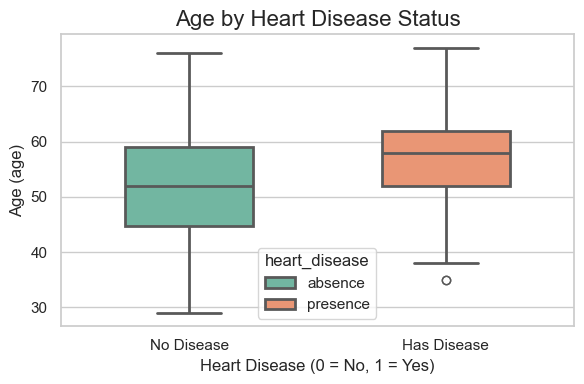

In [11]:
# Create the box plots to compare thalach for the different categories of heart desease
plt.figure(figsize=(6, 4))  # Wider figure
sns.set(style="whitegrid")  # Cleaner background
sns.boxplot(x='heart_disease', y='age',data=heart,palette='Set2', linewidth=2, width=0.5, hue='heart_disease', legend=True)
# Add labels and title
plt.title('Age by Heart Disease Status', fontsize=16)
plt.xlabel('Heart Disease (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Age (age)', fontsize=12)
# Make x-axis tick labels cleaner
plt.xticks([0, 1], ['No Disease', 'Has Disease'])
# Show the figure with tight layout for better readability
plt.tight_layout()
plt.show()

In [12]:
age_hd = heart[heart['heart_disease'] == 'presence']['age']
age_no_hd = heart[heart['heart_disease'] == 'absence']['age']

In [13]:
# Run Two-Sample T-Test to see if there is an association between the binary categorical variable heart_disease and the quantitative variable age
tstat, pval = ttest_ind(age_hd, age_no_hd)
print(f'T-statistic: {tstat}\nP-value: {pval}')

T-statistic: 3.971100226293655
P-value: 8.955636917529706e-05


### Serum Cholesterol in mg/dl (chol) vs Heart Disease (heart_disease)

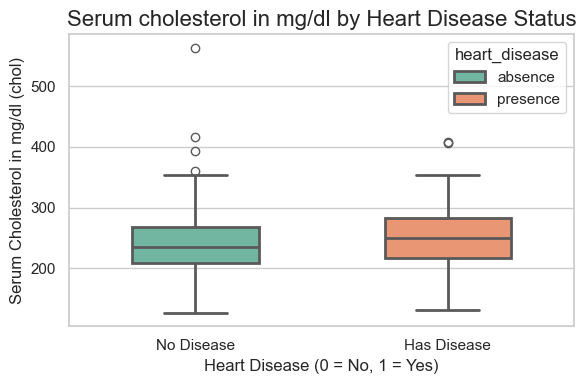

In [14]:
# Create the box plots to compare chol for the different categories of heart desease
plt.figure(figsize=(6, 4))  # Wider figure
sns.set(style="whitegrid")  # Cleaner background
sns.boxplot(x='heart_disease', y='chol',data=heart,palette='Set2', linewidth=2, width=0.5, hue='heart_disease', legend=True)
# Add labels and title
plt.title('Serum cholesterol in mg/dl by Heart Disease Status', fontsize=16)
plt.xlabel('Heart Disease (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Serum Cholesterol in mg/dl (chol)', fontsize=12)
# Make x-axis tick labels cleaner
plt.xticks([0, 1], ['No Disease', 'Has Disease'])
# Show the figure with tight layout for better readability
plt.tight_layout()
plt.show()

In [15]:
# Run Two-Sample T-Test to see if there is an association between the binary categorical variable heart_disease and the quantitative variable chol
# Split the datasets
chol_hd = heart[heart['heart_disease'] == 'presence']['chol']
chol_no_hd = heart[heart['heart_disease'] == 'absence']['chol']

tstat, pval = ttest_ind(chol_hd, chol_no_hd)
print(f'T-statistic: {tstat}\nP-value: {pval}')

T-statistic: 1.4829209163941466
P-value: 0.13914167020436527


### Maximum heart rate (thalach) vs Type of Chest Pain (cp) - ANOVA Test

Are there any chest pain types for which average thalach is significantly higher or lower (compared to other chest pain types)?

+ **Null**: People with typical angina, non-anginal pain, atypical angina, and asymptomatic people all have the same average thalach.
+ **Alternative**: People with typical angina, non-anginal pain, atypical angina, and asymptomatic people do not all have the same average thalach.

This test addresses an association between two variables: a non-binary categorical variable (cp, with four possible options) and a quantitative variable (thalach). We could use six separate two-sample t-tests here, but since we’ve been asked to use a single hypothesis test, we should use an ANOVA.

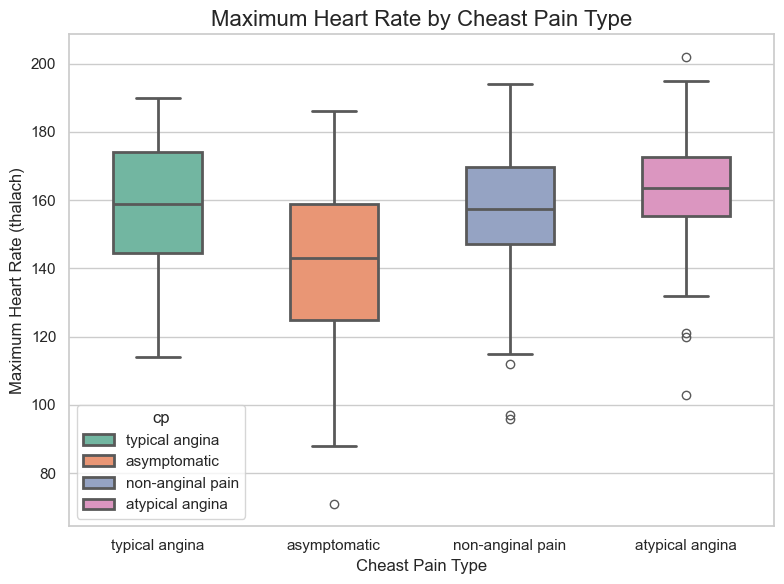

In [16]:
# Evaluate the association between the quantitative thalach and the categorical nominal variable cp
plt.figure(figsize=(8, 6))  # Wider figure
sns.set(style="whitegrid")  # Cleaner background
sns.boxplot(x='cp', y='thalach',data=heart,palette='Set2', linewidth=2, width=0.5, hue='cp', legend=True)
# Add labels and title
plt.title('Maximum Heart Rate by Cheast Pain Type', fontsize=16)
plt.xlabel('Cheast Pain Type', fontsize=12)
plt.ylabel('Maximum Heart Rate (thalach)', fontsize=12)
# Show the figure with tight layout for better readability
plt.tight_layout()
plt.show()

In [17]:
thalach_typical = heart[heart['cp'] == 'typical angina']['thalach']
thalach_asymptom = heart[heart['cp'] == 'asymptomatic']['thalach']
thalach_nonangin = heart[heart['cp'] == 'non-anginal pain']['thalach']
thalach_atypical = heart[heart['cp'] == 'atypical angina']['thalach']

# Run an ANOVA test to identify if there are significant differences in the maximum heart rate for the various categories of chest pain. 
fstat, pval = f_oneway(thalach_typical, thalach_asymptom, thalach_nonangin, thalach_atypical)

if pval < 0.05:
  print(f'There is a significant difference between at least one pair of categories {pval}')
else:
  print(f'The p-value of {pval} shows no significance among any of the groups')

There is a significant difference between at least one pair of categories 1.9065505247705742e-10


### Tukey's Range Test

Hypothesis test to determine which of those pairs are significantly different.For this test, we need Tukey’s range test, which can be implemented with pairwise_tukeyhsd.

For any pair where “Reject” is “True”, we conclude that people with those chest pain types have significantly different maximum heart rates during exercise. Note: you may need to expand the output window to see the full chart.

Maybe surprisingly, people who are 'asymptomatic' seem to have a lower maximum heart rate (associated with heart disease) than people who have other kinds of chest pain.

In [18]:
# To identify which groups are significantly different we will complement the anova analysis with Tukey's Range Test
tukey_results = pairwise_tukeyhsd(heart.thalach, heart.cp, 0.05)
print(tukey_results)

# The results conclude that there is a significant difference between the following groups: asymptomatic & atypical angina, asymptomatic & non-anginal pain, asymptomatic & typical angina. 
# The rest of the pairs of groups are not significantly different.

           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------
    asymptomatic  atypical angina  21.7394    0.0  12.7442 30.7347   True
    asymptomatic non-anginal pain  14.7264    0.0   7.2583 22.1945   True
    asymptomatic   typical angina   15.276 0.0081   2.9707 27.5812   True
 atypical angina non-anginal pain   -7.013 0.2481 -16.7587  2.7327  False
 atypical angina   typical angina  -6.4635 0.6213 -20.2702  7.3432  False
non-anginal pain   typical angina   0.5495 0.9995 -12.3145 13.4136  False
-------------------------------------------------------------------------


### Chi-Square for Gender (sex) vs Heart Disease (heart_disease)

+ **Null**: There is NOT an association between sex and whether or not someone is diagnosed with heart disease.
+ **Alternative**: There is an association between sex and whether or not someone is diagnosed with heart disease.

This test investigates an association between two categorical variables, so we need to use a Chi-Square test.

In [19]:
contingency_table = pd.crosstab(heart.sex, heart.heart_disease)
print(contingency_table)

heart_disease  absence  presence
sex                             
female              72        25
male                92       114


In [20]:
chi2, pval, dof, expected = chi2_contingency(contingency_table)
print(f'Chi2: {chi2}\nP-value: {pval}\nDegrees of Freedom: {dof}\nExpected Frequencies:\n{expected}')

Chi2: 22.042560606155472
P-value: 2.666712348180942e-06
Degrees of Freedom: 1
Expected Frequencies:
[[ 52.50165017  44.49834983]
 [111.49834983  94.50165017]]


### Fisher’s Exact Test

In [21]:
# Only works on 2x2 tables
odds_ratio, pval = fisher_exact(contingency_table)

print(odds_ratio, pval)

3.568695652173913 1.2589439001519763e-06


#### 🔍 What does that mean?
##### ✅ p-value = 1.26e-06
Extremely small — statistically significant. This means:
+ There's strong evidence of an association between sex and heart_disease.
+ You would reject the null hypothesis of no association.

##### 💡 odds_ratio = 3.57
This means:
+ The odds of having heart disease for one sex (most likely males, if sex = 1) are 3.57 times higher than for the other (females).
+ So gender is a significant predictor or associated factor with heart disease presence in your dataset.

### Chest Pain Type (cp) vs Heart Disease (heart_disease) - Chi-Square

+ **Null**: There is NOT an association between chest pain type and whether or not someone is diagnosed with heart disease.
+ **Alternative**: There is an association between chest pain type and whether or not someone is diagnosed with heart disease.

This test investigates an association between two categorical variables, so we need to use a Chi-Square test.

In [22]:
# Finally we will investigate the relationship or association between 2 categorical variables (of any number of levels) by using a Chi-Square hypothesis test.
Xtab = pd.crosstab(heart.cp, heart.heart_disease)
print(Xtab)

chi2, pval, dof, expected = chi2_contingency(Xtab)
print(chi2, pval, dof, expected) # The p-value is below the threshold of 0.05 so we can conclude there is a significant association between these variables


heart_disease     absence  presence
cp                                 
asymptomatic           39       105
atypical angina        41         9
non-anginal pain       68        18
typical angina         16         7
81.81577027653815 1.2517106007837527e-17 3 [[77.94059406 66.05940594]
 [27.06270627 22.93729373]
 [46.54785479 39.45214521]
 [12.44884488 10.55115512]]
